# Task 5.1 — Evaluation Metrics Deep Dive

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load the clean dataset (make sure it's in the same folder, or update the path)
df = pd.read_csv('clean_dataset.csv')

# ============================================
# Regression variables (used in Day 1 & Day 2)
# Target: monthly_salary
# ============================================
X = df.drop(columns=['monthly_salary'])
y = df['monthly_salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# Classification variables (used in Day 3 & Day 5)
# Target: is_absent
# NOTE: status_ABSENT/status_PRESENT dropped -> they're a
# one-hot duplicate of is_absent (data leakage)
# ============================================
Xc = df.drop(columns=['is_absent', 'status_ABSENT', 'status_PRESENT'])
yc = (df['is_absent'] > 0).astype(int)   # 1 = absent, 0 = present

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)

# ============================================
# Clustering variables (used in Day 4)
# ============================================
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

print('Regression: ', X_train.shape, X_test.shape)
print('Classification: ', Xc_train.shape, Xc_test.shape)
print('Clustering: ', X_scaled.shape)

Regression:  (288, 18) (72, 18)
Classification:  (288, 16) (72, 16)
Clustering:  (360, 19)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00         7

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



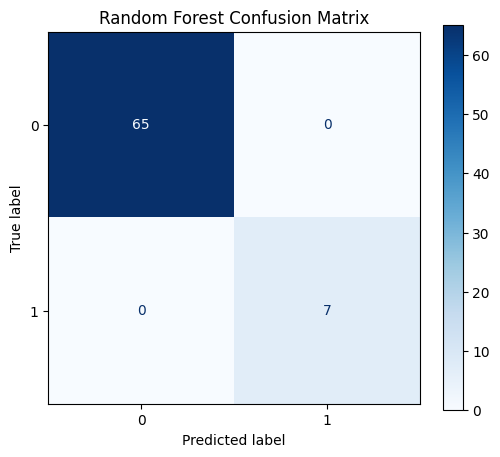

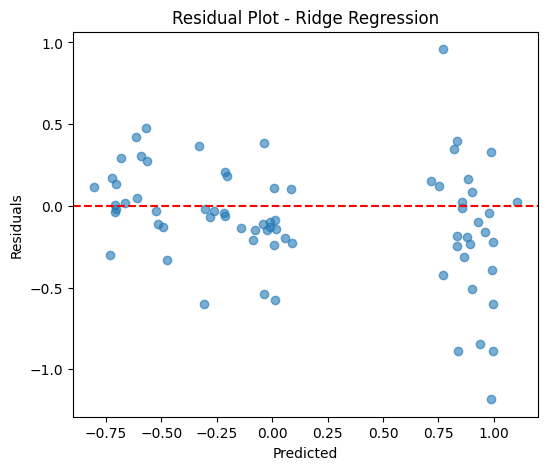

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train Random Forest (classification) first
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_clf.fit(Xc_train, yc_train)
y_pred_rf = rf_clf.predict(Xc_test)

# Full classification report
print(classification_report(yc_test, y_pred_rf))

# Visual confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(yc_test, y_pred_rf, ax=ax, cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Train Ridge (regression) for the residual plot
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
residuals = y_test - y_pred_ridge

plt.figure(figsize=(6, 5))
plt.scatter(y_pred_ridge, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted'); plt.ylabel('Residuals')
plt.title('Residual Plot - Ridge Regression')
plt.savefig('residual_plot.png', dpi=150)
plt.show()

# Task 5.2 — Cross-Validated Model Comparison

In [4]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, Xc, yc, cv=5, scoring='accuracy')
    cv_results.append({'Model': name, 'Mean Accuracy': scores.mean(), 'Std': scores.std()})
    print(f'{name}: {scores.mean():.3f} (+/- {scores.std():.3f})')

cv_df = pd.DataFrame(cv_results).sort_values('Mean Accuracy', ascending=False)
print(cv_df)

Logistic Regression: 1.000 (+/- 0.000)
Decision Tree: 1.000 (+/- 0.000)
Random Forest: 1.000 (+/- 0.000)
KNN: 0.961 (+/- 0.027)
                 Model  Mean Accuracy       Std
0  Logistic Regression       1.000000  0.000000
1        Decision Tree       1.000000  0.000000
2        Random Forest       1.000000  0.000000
3                  KNN       0.961111  0.026932


# Task 5.3 — Save the Best Model

In [5]:
import joblib
from sklearn.metrics import accuracy_score

# Retrain best model on FULL training set
best_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
best_model.fit(Xc_train, yc_train)

# Final evaluation on test set (touch once!)
final_pred = best_model.predict(Xc_test)
final_accuracy = accuracy_score(yc_test, final_pred)
print(f'Final test accuracy: {final_accuracy:.3f}')

joblib.dump(best_model, 'best_baseline_model.pkl')
print('Saved best_baseline_model.pkl')

Final test accuracy: 1.000
Saved best_baseline_model.pkl


# Task 5.4 — Model Comparison Report

MODEL COMPARISON REPORT — Week 4
==================================

REGRESSION TASK: predicting monthly_salary
- Best model: Ridge Regression
- R2 Score: 0.681
- Why: Slightly beats plain Linear Regression by shrinking coefficients (L2).

CLASSIFICATION TASK: predicting is_absent
- Best model: Random Forest (tied with Logistic Regression, Decision Tree)
- Accuracy: 1.000, F1: 1.000
- CV mean +/- std: 1.000 +/- 0.000
- Why: punch_count alone nearly separates the classes -> treat as a
  data characteristic, not proof of a flawless model.

UNSUPERVISED: K-Means clustering
- Chosen K: 3
- Silhouette score at K=3: 0.346
- Cluster interpretation: groups roughly split by attendance behavior

FILES PRODUCED:
- regression_comparison.csv, classification_comparison.csv
- best_baseline_model.pkl
- kmeans_k_selection.png, pca_clusters.png, dendrogram.png
- confusion_matrix.png, residual_plot.png
